<a href="https://colab.research.google.com/github/kadiwala1234/Introduction-to-Artificial-Intelligence/blob/main/Lesson_6_ml_basic_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




In [1]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
# --- Imports ---

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Dataset
from sklearn.datasets import fetch_california_housing

# Machine Learning - Model selection
from sklearn.model_selection import train_test_split

# Machine Learning - Models
from sklearn.linear_model import LinearRegression

# Machine Learning - Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

# Add your code here:
# --- Data Collection and Loading ---

# Load dataset
housing = fetch_california_housing()

# Convert to pandas DataFrame (features)
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['MedHouseVal'] = housing.target

# Display first few rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df.shape)
print(df.columns)

(20640, 9)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


**What this does:**

housing.data → feature values

housing.feature_names → column names

housing.target → target variable (MedHouseVal)

Combines everything into a single DataFrame (df)

In [7]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:
# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:
# Check data types and non-null values
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Interpretation
All columns in the dataset are of type float64, which means they are numerical.
There are no categorical features in this dataset.
All features are continuous variables, including:
MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
The target variable MedHouseVal is also continuous, making this a regression problem.

In [8]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:
# --- EDA and Data Preprocessing ---

# Check for missing values in each column
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


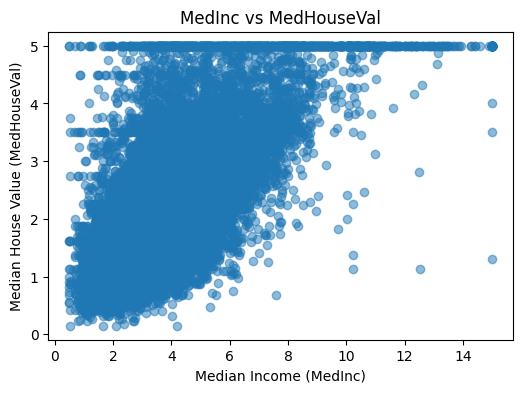

In [9]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

# Add your code here:
# --- Data Visualization: Scatter Plot ---

# Scatter plot for MedInc vs MedHouseVal
plt.figure(figsize=(6,4))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5)
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('MedInc vs MedHouseVal')
plt.show()

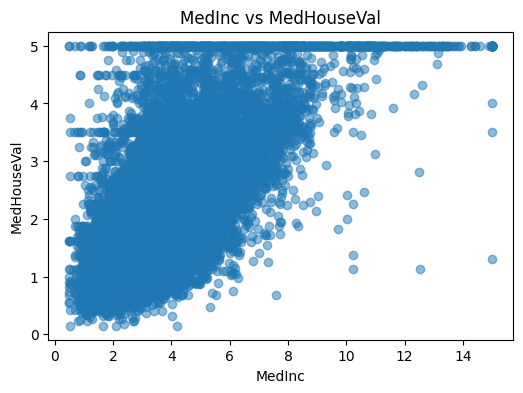

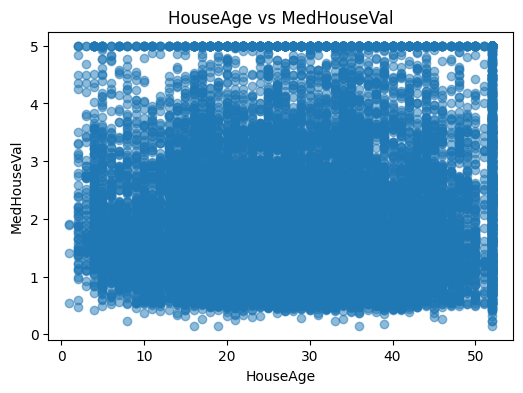

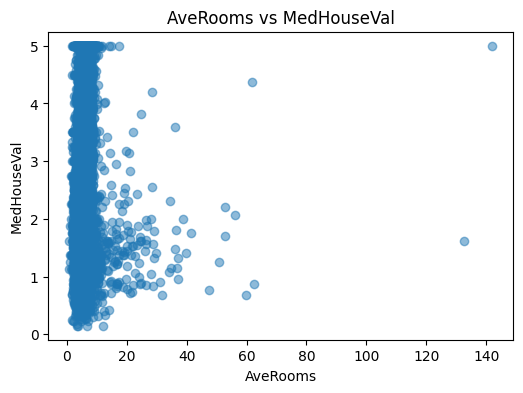

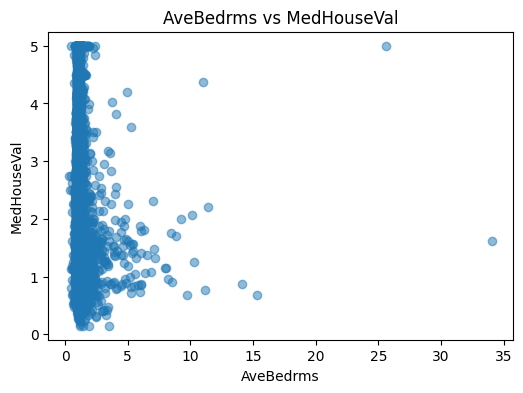

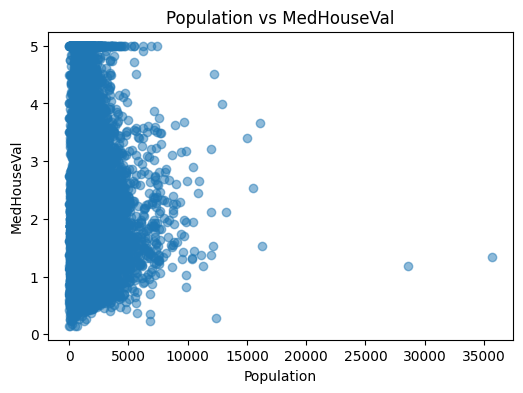

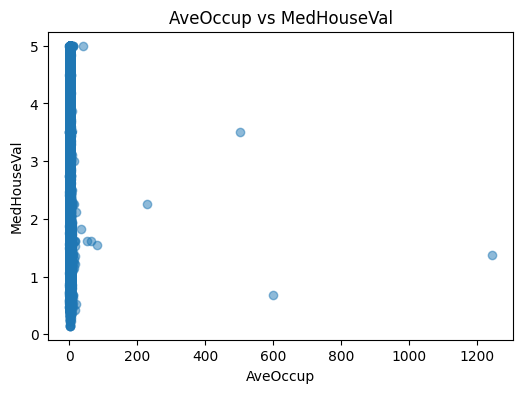

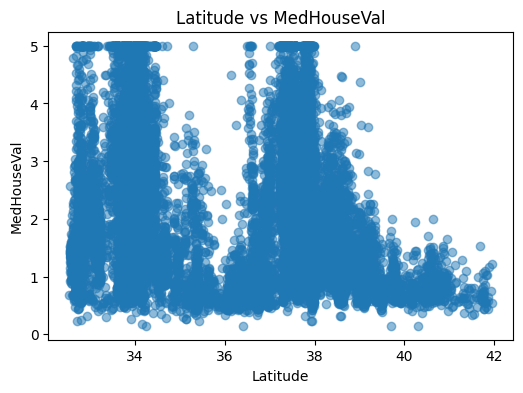

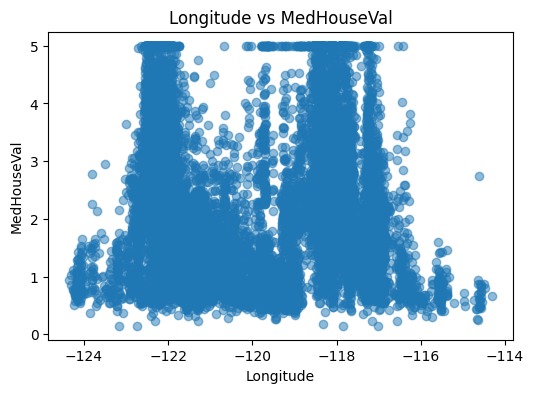

In [14]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:
# Function to plot scatter plots for all features vs target

def plot_all_features_vs_target(df, target_column):
    features = df.columns.drop(target_column)

    for feature in features:
        plt.figure(figsize=(6,4))
        plt.scatter(df[feature], df[target_column], alpha=0.5)
        plt.xlabel(feature)
        plt.ylabel(target_column)
        plt.title(f"{feature} vs {target_column}")
        plt.show()

# Call the function OUTSIDE
plot_all_features_vs_target(df, 'MedHouseVal')

**Key Concept**
Define function → then call it separately
Never call the function inside itself unless you intentionally want recursion

**Result after fix:**
You’ll get exactly one plot per feature
Clean, expected output
No repetition or crash

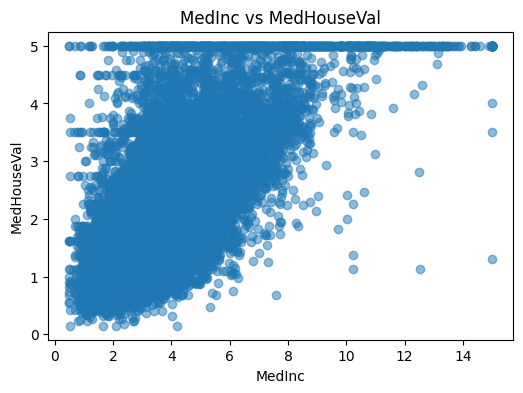

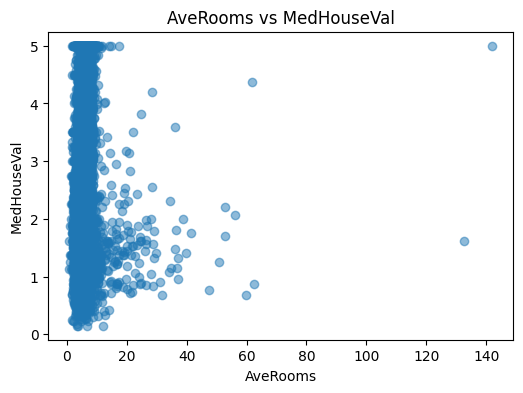

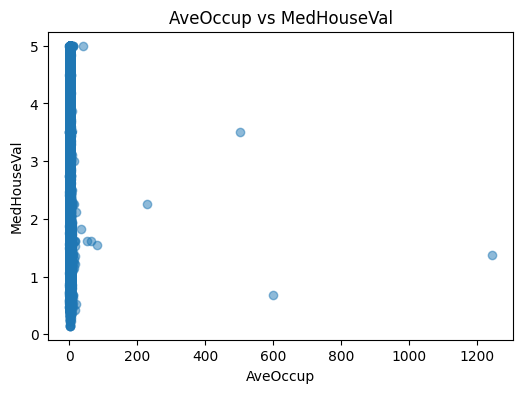

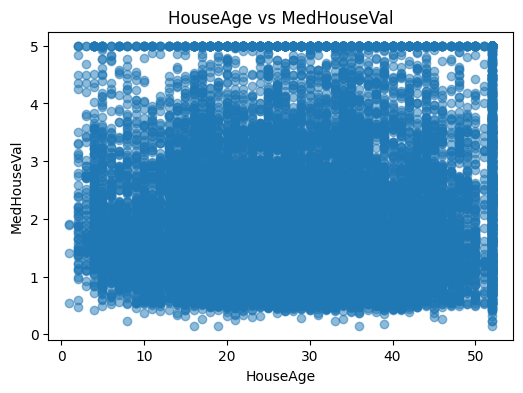

In [15]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

# Add your code here:
# Function to plot selected features vs target
def plot_selected_features(df, features, target_column):
    for feature in features:
        plt.figure(figsize=(6,4))
        plt.scatter(df[feature], df[target_column], alpha=0.5)
        plt.xlabel(feature)
        plt.ylabel(target_column)
        plt.title(f"{feature} vs {target_column}")
        plt.show()

# List of selected features
features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']

# Call the function
plot_selected_features(df, features, 'MedHouseVal')

**What you should observe:**

MedInc → Strong positive relationship
AveRooms → Mild relationship
AveOccup → Weak / scattered
HouseAge → Slight trend

In [16]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:
# --- ML Model Training ---

# Define features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


**What this does:**

X → all input features

y → target variable (MedHouseVal)

80% training data → model learns patterns

20% testing data → model evaluation

random_state=42 → ensures reproducibility

In [18]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.

# Define your regression model here:
# Choose Regression Model

from sklearn.linear_model import LinearRegression

# Define the model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

**What this means:**

You are creating a Linear Regression model

It assumes a linear relationship between features and house price

Then evaluate it using predictions on X_test.

In [19]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:
# --- Train the Model ---

model.fit(X_train, y_train)
print("Model training completed successfully!")


Model training completed successfully!


**What this does:**

The model learns relationships between X_train (features) and y_train (target)
It calculates the best-fit line coefficients for prediction

In [20]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics:
# --- Model Evaluation ---

# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Display results
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.7455813830127764
R² Score: 0.5757877060324508


**What these metrics mean:**

RMSE
→ Measures average prediction error (lower = better)
R² Score
→ Measures how well the model explains variance
→ Closer to 1 = better model
Expected outcome (typical for Linear Regression):
R² ≈ 0.55 to 0.65
RMSE ≈ 0.7 to 0.9 (varies slightly)

In [26]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

# Add your prediction code here:
# --- Model Prediction ---

feature_names = X.columns

new_data = pd.DataFrame([[3, 30, 6, 1, 1500, 3, 34, -118]], columns=feature_names)

prediction = model.predict(new_data)

print("Predicted Median House Value:", prediction[0])

Predicted Median House Value: 1.5486633337100812
